# Logistic Regression Tuning

| | |
|---|---|
| **Algorithm** | LogisticRegression |
| **Dataset** | Diabetes (Pima Indians), 2,000 (augmented) |
| **Task** | Binary Classification (당뇨 여부) |
| **Metric** | CV Accuracy, CV F1 — 5-fold StratifiedKFold |

## 튜닝 포인트

| # | 튜닝 | 내용 | 기대 효과 |
|---|---|---|---|
| 1 | **C (정규화 강도)** | 로그 스케일로 탐색 | 과적합 / 과소적합 균형 조정 |
| 2 | **l1_ratio** | l2(0) vs l1(1) 비교 | l1_ratio=1은 불필요한 feature 계수를 0으로 → feature selection 효과 |
| 3 | **class_weight** | balanced 적용 | 클래스 불균형(65:35) 보정 |
| 4 | **GridSearchCV** | C + l1_ratio + class_weight 통합 탐색 | 최적 조합 자동 탐색 |

## Imports
---

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

## Data Loading
---
- `diabetes_2000.csv`: knn_tuning.ipynb에서 Gaussian noise augmentation으로 생성된 데이터 (원본 768 → 2,000)

In [23]:
df = pd.read_csv('../datasets/diabetes_2000.csv')
print(df.shape)
print(df['Outcome'].value_counts())
df.head()

(2000, 9)
Outcome
0    1302
1     698
Name: count, dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1,90.485110,83.156976,26.504492,215.639580,34.547358,0.233607,43,1
1,1,90.000000,62.000000,12.000000,43.000000,27.200000,0.580000,24,0
2,0,134.197203,93.034998,46.224706,145.441016,41.566676,0.361592,27,0
3,1,114.386104,65.126088,35.506463,202.080823,37.973453,0.248906,22,0
4,0,93.074134,67.934380,27.806508,128.313629,42.530146,0.406004,21,0


In [24]:
X = df.drop(columns='Outcome').values
y = df['Outcome'].values

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## Base Model
---
- StandardScaler + LogisticRegression(max_iter=1000, solver='saga'), 나머지 기본값 (C=1.0, l1_ratio=0)

In [25]:
base_pl = Pipeline([('scaler', StandardScaler()), ('lr', LogisticRegression(max_iter=1000, solver='saga', l1_ratio=0))])

base_acc = cross_val_score(base_pl, X, y, cv=cv, scoring='accuracy').mean()
base_f1  = cross_val_score(base_pl, X, y, cv=cv, scoring='f1').mean()
print(f'Base — CV Accuracy: {base_acc:.4f}  CV F1: {base_f1:.4f}')

Base — CV Accuracy: 0.7710  CV F1: 0.6316


## Tuning 1: C (정규화 강도)
---
- Loss function: `log-loss + (1/C) * ||w||²`
- C가 작을수록 정규화 강도 증가 → 계수를 0에 가깝게 강제 → 모델 단순화 (과적합 방지)
- C가 클수록 정규화 약함 → training data에 더 맞춤 (과소적합 방지)
- 데이터마다 최적 C가 다르므로 로그 스케일로 탐색한다.

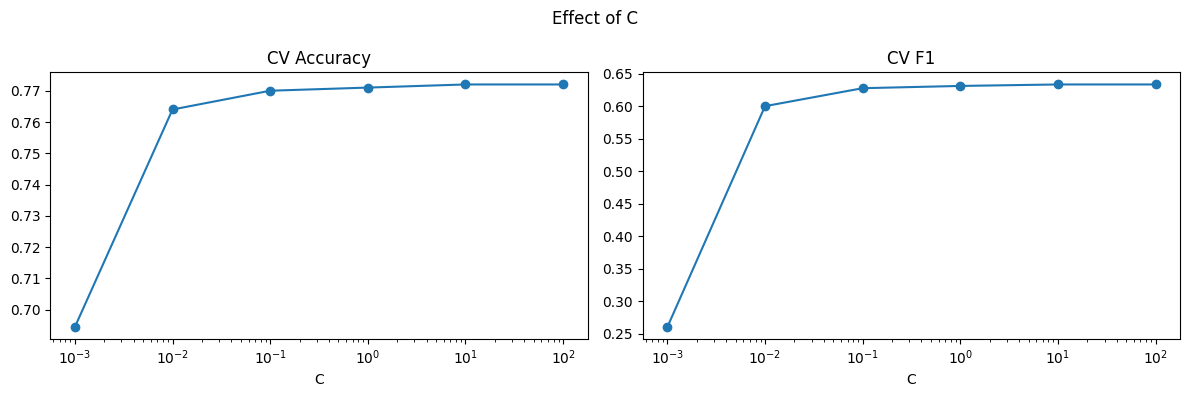

Best C (by F1): 10.0


In [26]:
C_values = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
accs, f1s = [], []

for c in C_values:
    pl = Pipeline([('scaler', StandardScaler()), ('lr', LogisticRegression(C=c, l1_ratio=0, solver='saga', max_iter=1000))])
    accs.append(cross_val_score(pl, X, y, cv=cv, scoring='accuracy').mean())
    f1s.append(cross_val_score(pl, X, y, cv=cv, scoring='f1').mean())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, vals, title in zip(axes, [accs, f1s], ['CV Accuracy', 'CV F1']):
    ax.plot(C_values, vals, marker='o')
    ax.set_xscale('log')
    ax.set_xlabel('C')
    ax.set_title(title)
plt.suptitle('Effect of C')
plt.tight_layout()
plt.show()

best_c = C_values[f1s.index(max(f1s))]
print(f'Best C (by F1): {best_c}')

## Tuning 2: l1_ratio 비교
---
- sklearn 1.8에서 `penalty` 파라미터가 deprecated → `l1_ratio`로 대체
- `l1_ratio=0`: L2 regularization — 모든 계수를 작게 유지, 안정적
- `l1_ratio=1`: L1 regularization — 불필요한 feature 계수를 정확히 0으로 → feature selection 효과
- `l1_ratio` 0~1 사이: Elastic Net (L1+L2 혼합)
- `solver='saga'`는 l1_ratio 모든 값 지원

| l1_ratio | 정규화 | 특징 |
|---|---|---|
| `0` (L2) | `\|\|w\|\|²` | 모든 계수를 작게 유지, 안정적 |
| `1` (L1) | `\|\|w\|\|` | 불필요한 feature 계수를 0으로 → feature selection |

In [27]:
results_penalty = {}
for name, l1_ratio in [('L2 (l1_ratio=0)', 0), ('L1 (l1_ratio=1)', 1)]:
    pl = Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(C=best_c, l1_ratio=l1_ratio, solver='saga', max_iter=1000))
    ])
    acc = cross_val_score(pl, X, y, cv=cv, scoring='accuracy').mean()
    f1  = cross_val_score(pl, X, y, cv=cv, scoring='f1').mean()
    results_penalty[name] = {'acc': acc, 'f1': f1}
    print(f'{name:20s} — CV Accuracy: {acc:.4f}  CV F1: {f1:.4f}')

# L1 계수 0 개수 확인
scaler = StandardScaler()
l1_model = LogisticRegression(C=best_c, l1_ratio=1, solver='saga', max_iter=1000)
l1_model.fit(scaler.fit_transform(X), y)
print(f'\nL1 zero coefs: {np.sum(l1_model.coef_ == 0)} / {l1_model.coef_.shape[1]}')

L2 (l1_ratio=0)      — CV Accuracy: 0.7720  CV F1: 0.6339
L1 (l1_ratio=1)      — CV Accuracy: 0.7720  CV F1: 0.6339

L1 zero coefs: 0 / 8


## Tuning 3: class_weight='balanced'
---
- Diabetes 데이터는 클래스 불균형 (Outcome 0: 65%, 1: 35%)
- `class_weight='balanced'`는 소수 클래스에 자동으로 더 높은 weight를 부여한다.
  - `weight_i = n_samples / (n_classes * count_i)`
- Recall이 올라가지만 Precision은 낮아질 수 있다. F1으로 종합 판단한다.

In [28]:
pl_bal = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(C=best_c, l1_ratio=0, solver='saga', class_weight='balanced', max_iter=1000))
])
bal_acc = cross_val_score(pl_bal, X, y, cv=cv, scoring='accuracy').mean()
bal_f1  = cross_val_score(pl_bal, X, y, cv=cv, scoring='f1').mean()
print(f'Balanced — CV Accuracy: {bal_acc:.4f}  CV F1: {bal_f1:.4f}')

Balanced — CV Accuracy: 0.7500  CV F1: 0.6674


## GridSearchCV: 통합 탐색
---
- C + l1_ratio + class_weight 조합을 한 번에 탐색한다
- `solver='saga'`는 l1_ratio 0~1 모두 지원 → 단일 param_grid로 통합 가능

In [29]:
pipeline = Pipeline([('scaler', StandardScaler()), ('lr', LogisticRegression(solver='saga', max_iter=1000))])

param_grid = {
    'lr__l1_ratio':     [0, 1],
    'lr__C':            [0.01, 0.1, 1, 10],
    'lr__class_weight': [None, 'balanced']
}

grid = GridSearchCV(pipeline, param_grid, cv=cv, scoring='f1', n_jobs=-1)
grid.fit(X, y)

print(f'Best params : {grid.best_params_}')
print(f'Best CV F1  : {grid.best_score_:.4f}')

grid_acc = cross_val_score(grid.best_estimator_, X, y, cv=cv, scoring='accuracy').mean()
grid_f1  = grid.best_score_

Best params : {'lr__C': 10, 'lr__class_weight': 'balanced', 'lr__l1_ratio': 0}
Best CV F1  : 0.6674


## 결과 비교
---
- 모든 모델을 동일한 5-fold StratifiedKFold CV로 평가

             Model  CV Accuracy    CV F1 Acc Delta F1 Delta
    Base (C=1, l2)        0.771 0.631586   +0.0000  +0.0000
Tuning 3: Balanced        0.750 0.667418   -0.0210  +0.0358
      GridSearchCV        0.750 0.667418   -0.0210  +0.0358


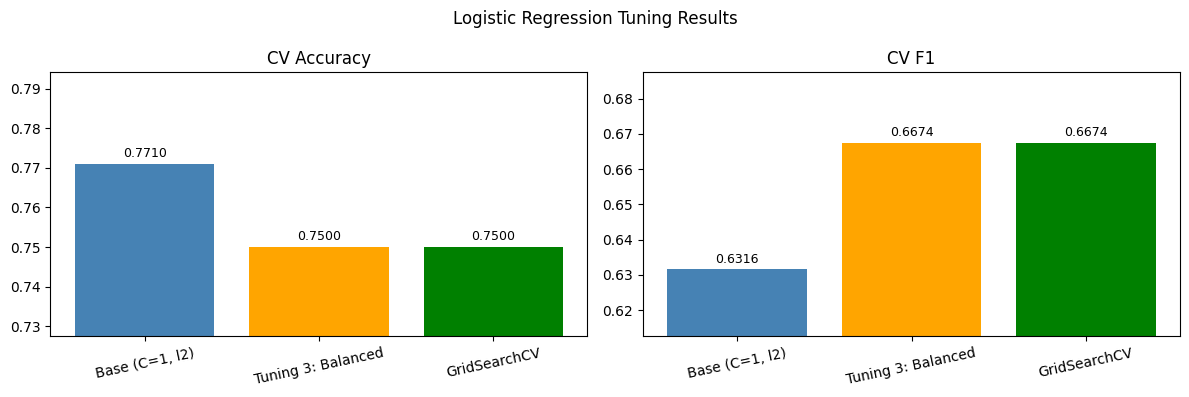

In [30]:
results = pd.DataFrame({
    'Model':       ['Base (C=1, l2)', 'Tuning 3: Balanced', 'GridSearchCV'],
    'CV Accuracy': [base_acc, bal_acc, grid_acc],
    'CV F1':       [base_f1,  bal_f1,  grid_f1]
})
results['Acc Delta'] = (results['CV Accuracy'] - base_acc).map(lambda x: f'{x:+.4f}')
results['F1 Delta']  = (results['CV F1']       - base_f1 ).map(lambda x: f'{x:+.4f}')
print(results.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ['CV Accuracy', 'CV F1']):
    bars = ax.bar(results['Model'], results[col], color=['steelblue', 'orange', 'green'])
    ax.set_ylim(results[col].min() * 0.97, results[col].max() * 1.03)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=12)
    for bar, val in zip(bars, results[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)
plt.suptitle('Logistic Regression Tuning Results')
plt.tight_layout()
plt.show()

In [31]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
final = GridSearchCV(pipeline, param_grid, cv=cv, scoring='f1', n_jobs=-1)
final.fit(X_train, y_train)
print(classification_report(y_test, final.predict(X_test), target_names=['No Diabetes', 'Diabetes']))

              precision    recall  f1-score   support

 No Diabetes       0.80      0.78      0.79       260
    Diabetes       0.61      0.63      0.62       140

    accuracy                           0.73       400
   macro avg       0.70      0.71      0.71       400
weighted avg       0.73      0.73      0.73       400

